In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [4]:
df = pd.read_csv("C:\\Data Analytics\\EDA\\EDA PROJECTS\\Road Accident\\indian_roads_dataset.csv")

In [5]:
df

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,Bangalore,Karnataka,13.092276,77.599571,2022-09-29,3:00,3,Thursday,0,...,high,31,low,distraction,minor,3,2,0,NaN,0.10
19996,19996,Chennai,Tamil Nadu,13.172928,80.157062,2023-11-25,1:00,1,Saturday,1,...,high,20,low,distraction,major,4,2,0,NaN,0.10
19997,19997,Chennai,Tamil Nadu,12.997170,80.150724,2022-06-18,15:00,15,Saturday,1,...,high,22,low,weather,minor,3,3,0,NaN,0.10
19998,19998,Kolkata,West Bengal,22.454882,88.322213,2023-03-12,4:00,4,Sunday,1,...,high,33,low,poor road,minor,1,0,0,NaN,0.10


In [6]:
df.isnull().sum()

accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64

In [7]:
df['festival'].value_counts()

festival
Holi        38
Eid         34
Diwali      31
New Year    12
Name: count, dtype: int64

In [8]:
df['festival'] = df['festival'].fillna('No festival')

In [9]:
df['festival'].value_counts()

festival
No festival    19885
Holi              38
Eid               34
Diwali            31
New Year          12
Name: count, dtype: int64

In [10]:
df.isnull().sum()

accident_id          0
city                 0
state                0
latitude             0
longitude            0
date                 0
time                 0
hour                 0
day_of_week          0
is_weekend           0
road_type            0
lanes                0
traffic_signal       0
weather              0
visibility           0
temperature          0
traffic_density      0
cause                0
accident_severity    0
vehicles_involved    0
casualties           0
is_peak_hour         0
festival             0
risk_score           0
dtype: int64

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  str    
 2   state              20000 non-null  str    
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  str    
 6   time               20000 non-null  str    
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  str    
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  str    
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  str    
 14  visibility         20000 non-null  str    
 15  temperature        20000 non-null  int64  
 16  traffic_density    20000 non-null

In [12]:
df['date'] = df['date'].str.strip()

In [13]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

In [14]:
print(df['date'].dtype)

datetime64[us]


In [15]:
df['time'].dtype

<StringDtype(storage='python', na_value=nan)>

In [16]:
df['time'] = df['time'].str.strip()

In [17]:
df['time'] = pd.to_datetime(df['time'], format='%H:%M').dt.time

In [18]:
df['time'].dtype

dtype('O')

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   accident_id        20000 non-null  int64         
 1   city               20000 non-null  str           
 2   state              20000 non-null  str           
 3   latitude           20000 non-null  float64       
 4   longitude          20000 non-null  float64       
 5   date               20000 non-null  datetime64[us]
 6   time               20000 non-null  object        
 7   hour               20000 non-null  int64         
 8   day_of_week        20000 non-null  str           
 9   is_weekend         20000 non-null  int64         
 10  road_type          20000 non-null  str           
 11  lanes              20000 non-null  int64         
 12  traffic_signal     20000 non-null  int64         
 13  weather            20000 non-null  str           
 14  visibility       

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.dtypes

accident_id                   int64
city                            str
state                           str
latitude                    float64
longitude                   float64
date                 datetime64[us]
time                         object
hour                          int64
day_of_week                     str
is_weekend                    int64
road_type                       str
lanes                         int64
traffic_signal                int64
weather                         str
visibility                      str
temperature                   int64
traffic_density                 str
cause                           str
accident_severity               str
vehicles_involved             int64
casualties                    int64
is_peak_hour                  int64
festival                        str
risk_score                  float64
dtype: object

In [22]:
df.describe()

,accident_id,latitude,longitude,date,hour,is_weekend,lanes,traffic_signal,temperature,vehicles_involved,casualties,is_peak_hour,risk_score
count,20000.000000,20000.000000,20000.000000,20000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,9999.500000,20.389207,78.173330,2023-08-22 07:04:48,11.487200,0.286150,3.493950,0.499850,27.579600,2.992000,1.726450,0.247400,0.437585
min,0.000000,12.800172,72.700017,2022-01-01 00:00:00,0.000000,0.000000,1.000000,0.000000,15.000000,1.000000,0.000000,0.000000,0.100000
25%,4999.750000,13.198653,73.997979,2022-10-25 00:00:00,5.000000,0.000000,2.000000,0.000000,21.000000,2.000000,1.000000,0.000000,0.250000
50%,9999.500000,18.812008,77.297000,2023-08-21 00:00:00,12.000000,0.000000,4.000000,0.000000,28.000000,3.000000,1.000000,0.000000,0.450000
75%,14999.250000,28.402467,80.111089,2024-06-21 00:00:00,18.000000,1.000000,5.000000,1.000000,34.000000,4.000000,3.000000,0.000000,0.600000
max,19999.000000,30.799960,88.499861,2025-04-15 00:00:00,23.000000,1.000000,6.000000,1.000000,40.000000,5.000000,5.000000,1.000000,1.000000
std,5773.647028,6.165791,4.485967,NaN,6.945563,0.451972,1.705406,0.500012,7.454746,1.415534,1.489104,0.431512,0.218130


In [23]:
df.describe(include='object')

C:\Users\asus\AppData\Local\Temp\ipykernel_23220\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,city,state,time,day_of_week,road_type,weather,visibility,traffic_density,cause,accident_severity,festival
count,20000,20000,20000,20000,20000,20000,20000,20000,20000,20000,20000
unique,8,7,24,7,3,3,3,3,5,3,5
top,Chandigarh,Maharashtra,02:00:00,Monday,urban,clear,low,low,distraction,minor,No festival
freq,2577,5009,888,2966,6745,6690,9987,7067,4026,11025,19885


In [26]:
df.describe()

,accident_id,latitude,longitude,date,hour,is_weekend,lanes,traffic_signal,temperature,vehicles_involved,casualties,is_peak_hour,risk_score
count,20000.000000,20000.000000,20000.000000,20000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,9999.500000,20.389207,78.173330,2023-08-22 07:04:48,11.487200,0.286150,3.493950,0.499850,27.579600,2.992000,1.726450,0.247400,0.437585
min,0.000000,12.800172,72.700017,2022-01-01 00:00:00,0.000000,0.000000,1.000000,0.000000,15.000000,1.000000,0.000000,0.000000,0.100000
25%,4999.750000,13.198653,73.997979,2022-10-25 00:00:00,5.000000,0.000000,2.000000,0.000000,21.000000,2.000000,1.000000,0.000000,0.250000
50%,9999.500000,18.812008,77.297000,2023-08-21 00:00:00,12.000000,0.000000,4.000000,0.000000,28.000000,3.000000,1.000000,0.000000,0.450000
75%,14999.250000,28.402467,80.111089,2024-06-21 00:00:00,18.000000,1.000000,5.000000,1.000000,34.000000,4.000000,3.000000,0.000000,0.600000
max,19999.000000,30.799960,88.499861,2025-04-15 00:00:00,23.000000,1.000000,6.000000,1.000000,40.000000,5.000000,5.000000,1.000000,1.000000
std,5773.647028,6.165791,4.485967,NaN,6.945563,0.451972,1.705406,0.500012,7.454746,1.415534,1.489104,0.431512,0.218130


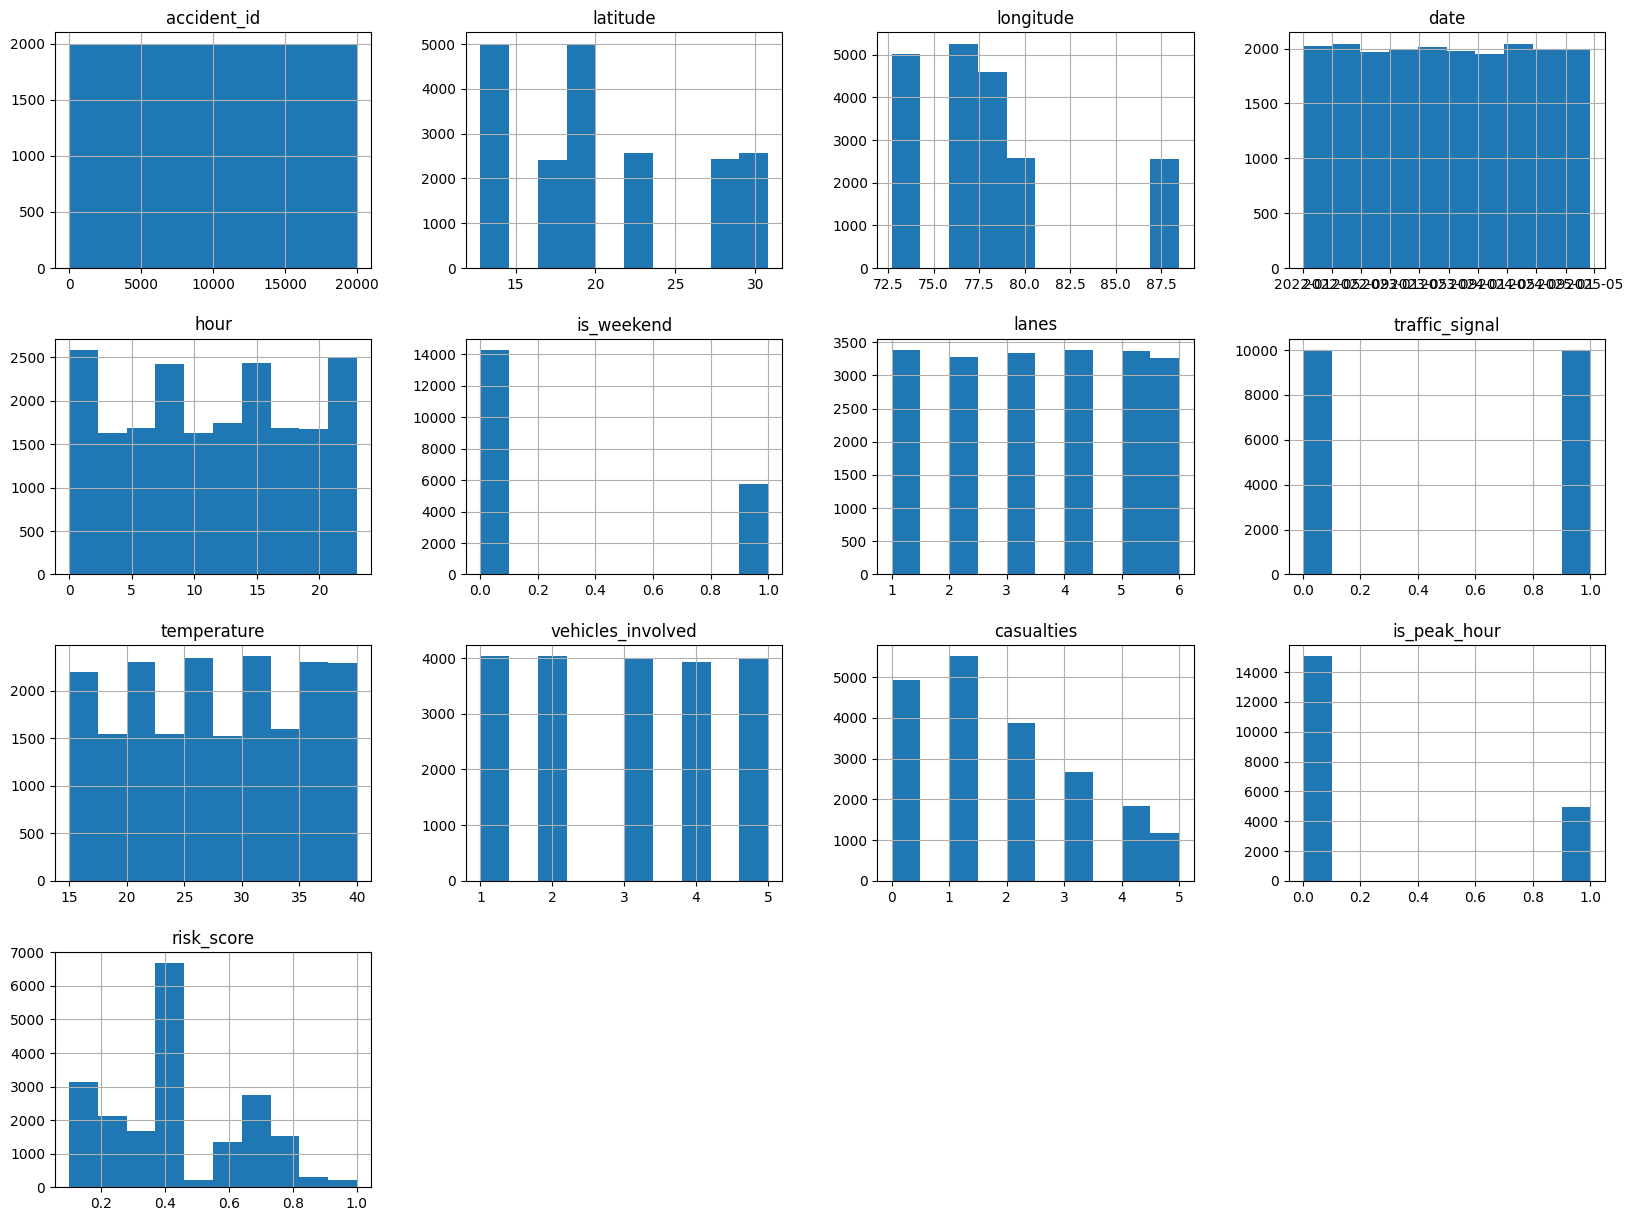

In [ ]:
df.hist(figsize=(20,15))
plt.show()

In [70]:
pd.crosstab(df['day_of_week'] , df['is_weekend'])

is_weekend,0,1
day_of_week,,
Friday,2879,0
Monday,2966,0
Saturday,0,2867
Sunday,0,2856
Thursday,2835,0
Tuesday,2871,0
Wednesday,2726,0


In [32]:
df['weather'].value_counts()

weather
clear    6690
rain     6677
fog      6633
Name: count, dtype: int64

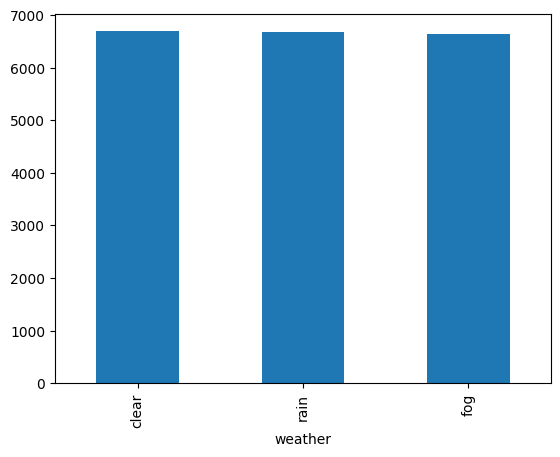

In [33]:
df['weather'].value_counts().plot(kind='bar')
plt.show()

In [35]:
pd.crosstab(df['weather'], df['accident_severity'])

accident_severity,fatal,major,minor
weather,,,
clear,992,2017,3681
fog,995,1975,3663
rain,1000,1996,3681


In [36]:
pd.crosstab(df['road_type'], df['accident_severity'])

accident_severity,fatal,major,minor
road_type,,,
highway,983,1967,3666
rural,965,2014,3660
urban,1039,2007,3699


In [78]:
df['casualties'].mean()

np.float64(1.72645)

In [77]:
df['accident_severity'].value_counts()

accident_severity
minor    11025
major     5988
fatal     2987
Name: count, dtype: int64

In [75]:
df.groupby('road_type') ['casualties'].mean()

road_type
highway    1.725967
rural      1.721795
urban      1.731505
Name: casualties, dtype: float64

In [89]:

df['cause'].value_counts()

cause
distraction      4026
overspeeding     4025
weather          3997
drunk driving    3978
poor road        3974
Name: count, dtype: int64

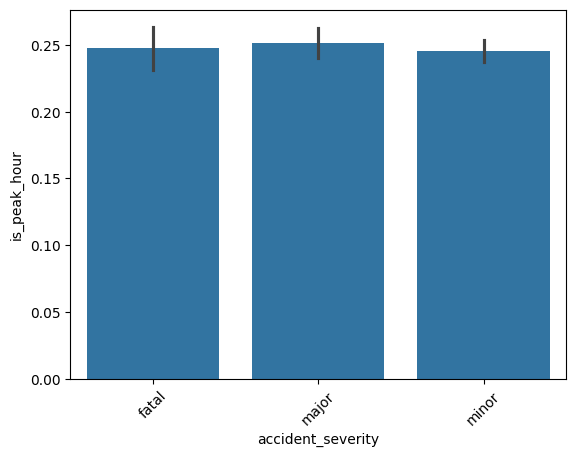

In [74]:
sns.barplot(x= 'accident_severity' , y='is_peak_hour' , data=df)
plt.xticks(rotation=45)
plt.show()

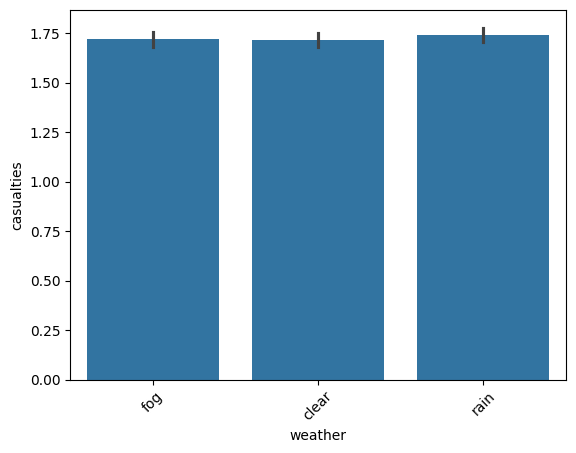

In [39]:
sns.barplot(x= 'weather' , y='casualties' , data=df)
plt.xticks(rotation=45)
plt.show()

In [41]:
df['month'] = df['date'].dt.month_name()

In [80]:
df['month'].value_counts()

month
January      2044
March        2043
February     1865
April        1763
May          1593
August       1588
July         1543
November     1533
December     1525
October      1516
June         1512
September    1475
Name: count, dtype: int64

<Axes: xlabel='month'>

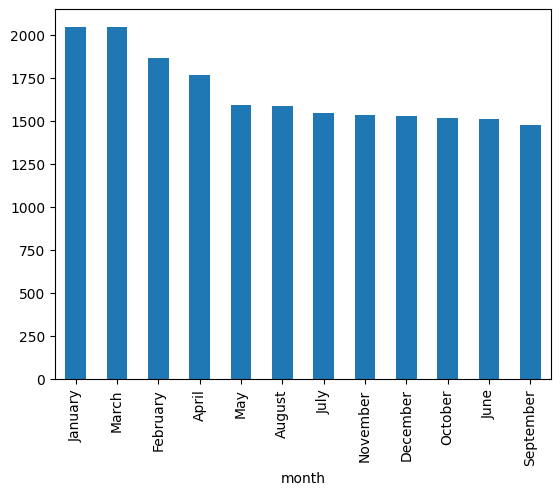

In [42]:
df['month'].value_counts().plot(kind='bar')

In [85]:
df.groupby('traffic_density')['accident_severity'].value_counts()

traffic_density  accident_severity
high             minor                3912
                 major                2077
                 fatal                1045
low              minor                3890
                 major                2116
                 fatal                1061
medium           minor                3223
                 major                1795
                 fatal                 881
Name: count, dtype: int64

<Axes: xlabel='day_of_week'>

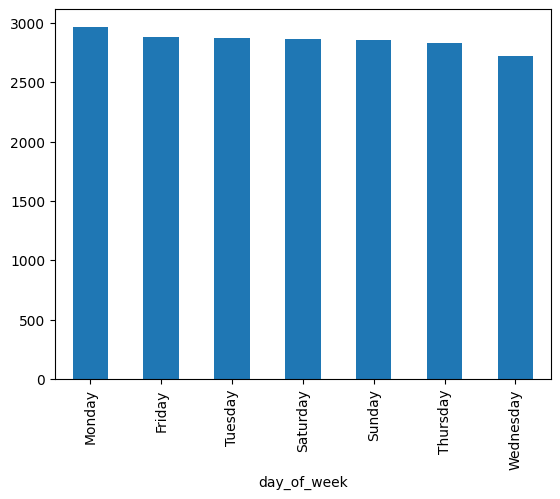

In [47]:
df['day_of_week'].value_counts().plot(kind='bar')

<Axes: xlabel='hour'>

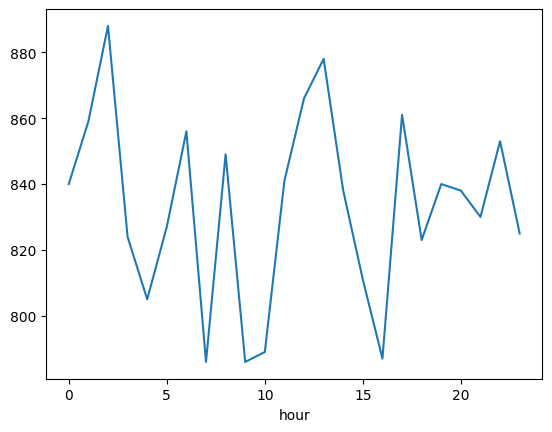

In [48]:
df.groupby('hour').size().plot(kind='line')

In [49]:
df['city'].value_counts().head(10)

city
Chandigarh    2577
Chennai       2575
Kolkata       2559
Pune          2517
Mumbai        2492
Bangalore     2438
Delhi         2433
Hyderabad     2409
Name: count, dtype: int64

In [50]:
df['state'].value_counts()

state
Maharashtra    5009
Punjab         2577
Tamil Nadu     2575
West Bengal    2559
Karnataka      2438
Delhi          2433
Telangana      2409
Name: count, dtype: int64

In [51]:
df['cause'].value_counts()

cause
distraction      4026
overspeeding     4025
weather          3997
drunk driving    3978
poor road        3974
Name: count, dtype: int64

In [52]:
df.groupby('weather')['casualties'].mean()

weather
clear    1.717638
fog      1.718981
rain     1.742699
Name: casualties, dtype: float64

In [53]:
df['accident_severity'].value_counts()

accident_severity
minor    11025
major     5988
fatal     2987
Name: count, dtype: int64

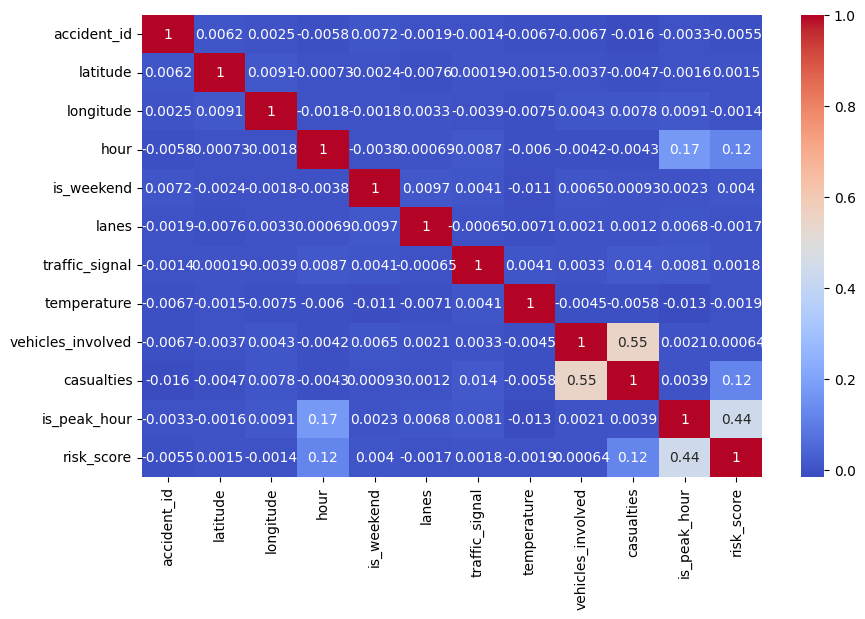

In [54]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()